# Event reconstruction for mono analysis

Our aim is to find the Hillas paramters for a simple monoscopic analysis.
refer to https://ctapipe.readthedocs.io/en/stable/auto_examples/tutorials/ctapipe_overview.html

For the file "gamma-diffuse_with_images_00.dl2.h5" 

Lets start with a bunch of imports...

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from ctapipe.io import EventSource
from ctapipe.visualization import CameraDisplay, ArrayDisplay
from ctapipe.reco import HillasReconstructor
from ctapipe.image import hillas_parameters, tailcuts_clean, timing_parameters
from ctapipe.image import brightest_island, number_of_islands
import math
import astropy.units as u
from astropy.coordinates import SkyCoord, AltAz
from ctapipe.coordinates import CameraFrame
from ctapipe.coordinates.utils import altaz_to_righthanded_cartesian


/Users/sarthaktripathy/Desktop/TIFR/Coursework/Sem_2/ACR/acr_setup_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read the file...

In [3]:
dl1_file = "../../gamma-diffuse_with_images_00.dl2.h5"

source = EventSource(
    input_url = dl1_file,
    max_events = None
)
subarray = source.subarray

Table /configuration/simulation/run is missing column None for field run_number of container <class 'ctapipe.containers.SimulationConfigContainer'>. It will be skipped.


Find all events on any one telescope (lets say TEL_ID = 10)

- How many events are there?

In [4]:
## listing events on telescope with tel_id = 10
mono_events = []
tel_id = 10
for event in source:
    if tel_id in event.dl1.tel:
        mono_events.append(event)
print(f"Number of events with telescope {tel_id} images: {len(mono_events)}")

Table /dl1/event/telescope/trigger is missing column event_type for field event_type of container <class 'ctapipe.containers.TelescopeTriggerContainer'>. It will be skipped.
Table /simulation/event/subarray/shower is missing column true_starting_grammage for field starting_grammage of container <class 'ctapipe.containers.SimulatedShowerContainer'>. It will be skipped.
Table /dl2/event/subarray/geometry/HillasReconstructor is missing column HillasReconstructor_ang_distance_uncert for field ang_distance_uncert of container <class 'ctapipe.containers.ReconstructedGeometryContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_psi_uncertainty for field psi_uncertainty of container <class 'ctapipe.containers.HillasParametersContainer'>. It will be skipped.
Table /dl1/event/telescope/parameters/tel_035 is missing column hillas_transverse_cog_uncertainty for field transverse_cog_uncertainty of container <class 'ctapipe.containers.HillasParameter

Number of events with telescope 10 images: 7570


In [5]:
# You can find the image data in the dl1 file
mono_events[0].dl1.tel[tel_id].image

array([ 1.2, -1.3, -1.1, ...,  0.4, -0.6,  2.7],
      shape=(1855,), dtype=float32)

- Plot the image for different event ids
- Clean the image using `tailcuts_clean` (use event id = 5) - How to decide thresholds?
- Find the number of islands
- get the brightest island
- compute the Hillas parameters
- overlay the Hillas parameters on the plot
- Plot the arrival time at each pixel
- compute the timing profile using `timing_parameters`
- Repeat for another few events to get a feel
- Now, repeat for all events (for performance issues, use ~1000 events)
- Find the simulated energy value for each event
- Plot the Hillas/timing parameters with energy - The n

/Users/sarthaktripathy/Desktop/TIFR/Coursework/Sem_2/ACR/acr_setup_env/lib/python3.12/site-packages/ctapipe/visualization/mpl_camera.py:593: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.axes.figure.show()


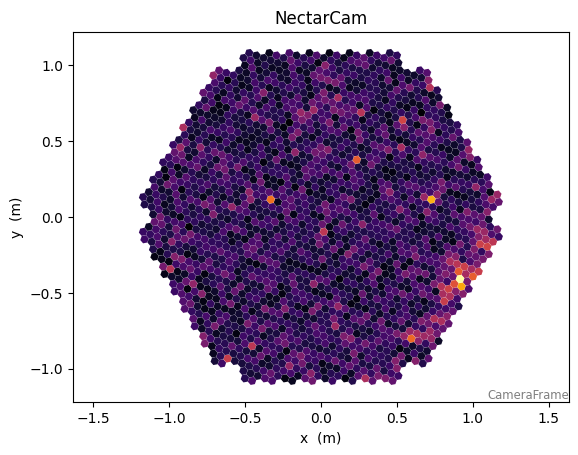

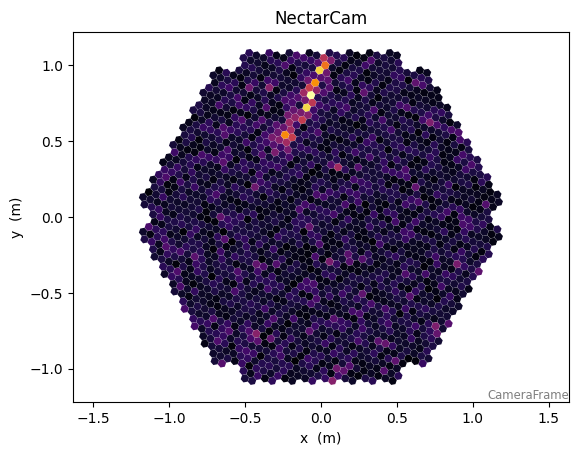

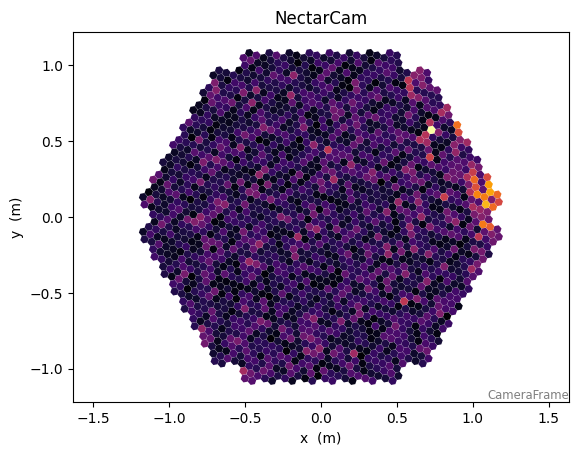

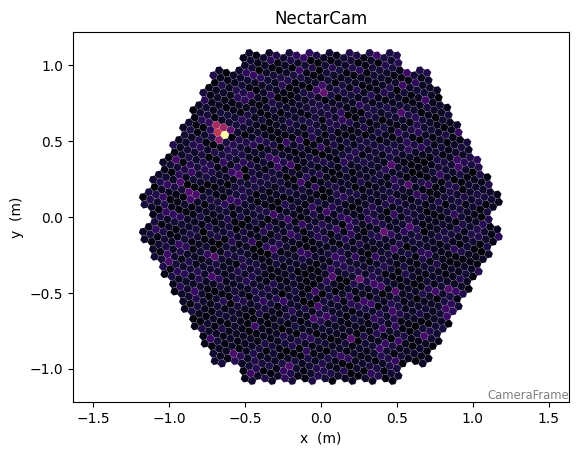

In [6]:
## plotting images for first four events in mono_events
tel_geom = source.subarray.tel[tel_id].camera.geometry
for i in range(4):
    plt.figure()
    image = mono_events[i].dl1.tel[tel_id].image
    display = CameraDisplay(tel_geom)
    display.image = image
    display.show()

#### Cleaning Image

Number of pixels remaining after cleaning: 16


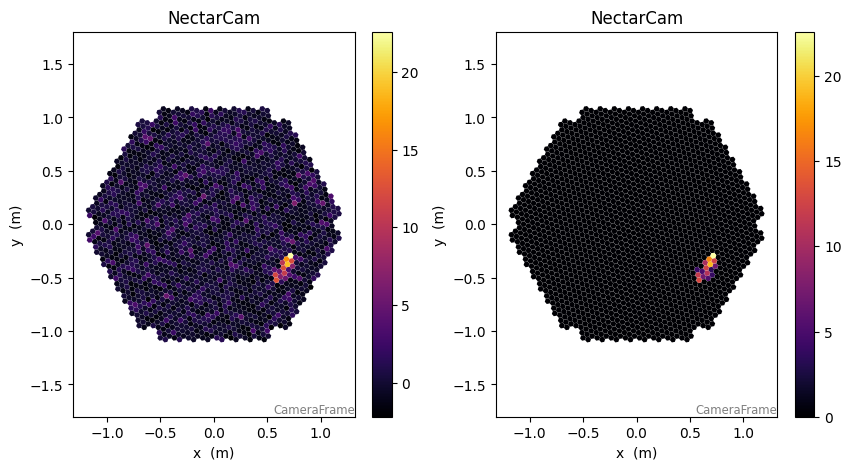

In [7]:
fig, axes =plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))
ev_id = 5

## choosing 5th image in mono_events for further analysis
image = mono_events[ev_id].dl1.tel[tel_id].image

axes[0].set_title("Original Image")
display1 = CameraDisplay(tel_geom, ax = axes[0])
display1.image = image
display1.add_colorbar(ax = axes[0])

## cleaning the image
clean_mask = tailcuts_clean(
    tel_geom,
    image,
    picture_thresh=6,
    boundary_thresh=3
)
cleaned_image = image.copy()
cleaned_image[~clean_mask] = 0

## plotting the cleaned image
axes[1].set_title("Cleaned Image")
display2 = CameraDisplay(tel_geom, ax = axes[1])
display2.image = cleaned_image
display2.add_colorbar(ax = axes[1])

## remaining pixles after cleaning
print(f"Number of pixels remaining after cleaning: {np.sum(clean_mask)}")

### Identifying Islands

In [8]:
## finding number of islands in the cleaned image
num_islands, island_labels = number_of_islands(tel_geom, clean_mask)
print(f"Number of islands in the cleaned image: {num_islands}")

Number of islands in the cleaned image: 1


### Hillas Parametrization

In [9]:
## since there is the only island, the brightest island is also the only island
## proceeding to Hllas parameterization
hillas_params = hillas_parameters(tel_geom[clean_mask], cleaned_image[clean_mask])
print("Hillas Parameters:")
for param, value in hillas_params.items():
    print(f"  {param}: {value}")

Hillas Parameters:
  intensity: 164.39999866485596
  skewness: -0.24910368155503895
  kurtosis: 1.8669790945374367
  x: 0.665356217878229 m
  y: -0.3996058940136744 m
  r: 0.7761338590730914 m
  phi: -0.5408527725092468 rad
  length: 0.08270886874011385 m
  length_uncertainty: 0.0030031394082616616 m
  width: 0.030952469030596386 m
  width_uncertainty: 0.001726894759140154 m
  psi: 1.0196665795279356 rad
  psi_uncertainty: 0.06209665468945685 rad
  transverse_cog_uncertainty: 0.0035563990074218197 m


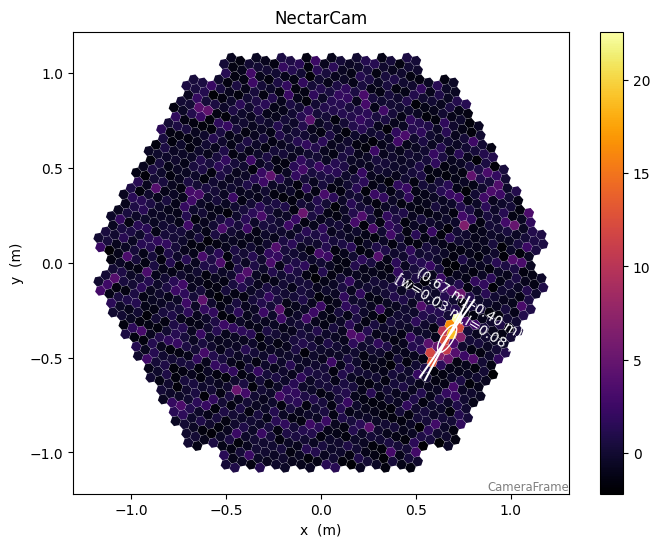

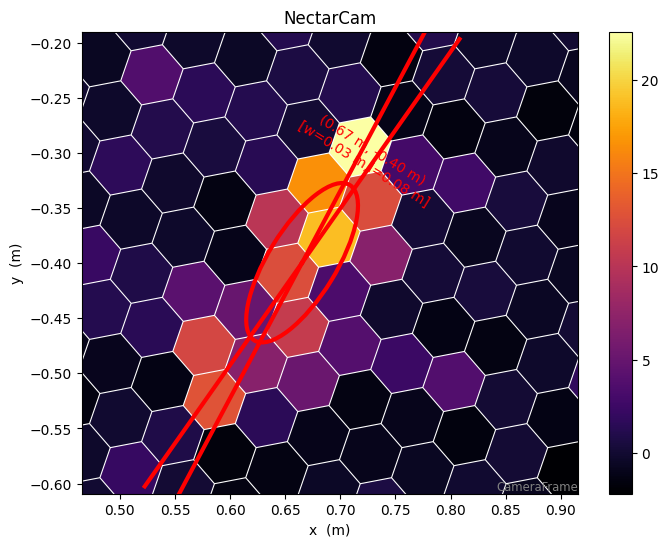

In [10]:
## overlaying Hillas parameters onto the original image
fig1= plt.figure()
fig1.set_size_inches(8, 6)
ax1= fig1.add_subplot(111)
ax1.set_title("Original Image with Hillas Parameters")
image = mono_events[ev_id].dl1.tel[tel_id].image
display = CameraDisplay(tel_geom)
display.image = image
display.add_colorbar(ax=ax1)
display.overlay_moments(hillas_params, color='white', label='Hillas Parameters')
plt.show()
## zommed in view of the image with Hillas parameters
fig2= plt.figure()
fig2.set_size_inches(8, 6)
ax2= fig2.add_subplot(111)
x_mid = hillas_params['x'].value
y_mid = hillas_params['y'].value
ax2.set_title("Zoomed-in View")
display_zoom = CameraDisplay(tel_geom, ax=ax2)
display_zoom.image = image
display_zoom.add_colorbar(ax=ax2)
display_zoom.overlay_moments(hillas_params, color='red', label='Hillas Parameters', linewidth=3)
ax2.set_xlim([x_mid - 0.2, x_mid + 0.25])
ax2.set_ylim([y_mid - 0.2, y_mid + 0.2])
plt.show()

### Timing Profile

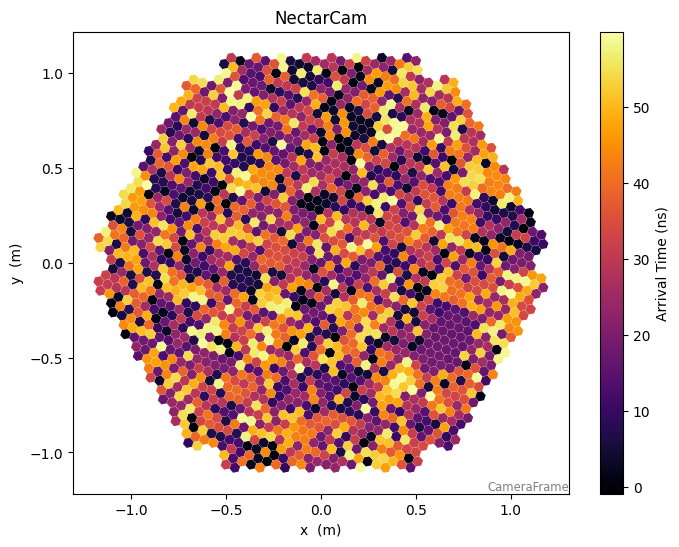

In [11]:
## displaying the arrival time on each pixel
fig = plt.figure()
fig.set_size_inches(8, 6)
ax = fig.add_subplot(111)
ax.set_title("Arrival Time on Each Pixel")
timing_params = timing_parameters(hillas_parameters=hillas_params, geom=tel_geom[clean_mask], image=cleaned_image, peak_time=mono_events[ev_id].dl1.tel[tel_id].peak_time[clean_mask])
display_timing = CameraDisplay(tel_geom, ax=ax)
display_timing.image = mono_events[ev_id].dl1.tel[tel_id].peak_time
display_timing.add_colorbar(ax=ax, label='Arrival Time (ns)')
plt.show()

### Timing Parameters

In [12]:
## computing timing profile using the timing parameters
t_slope = timing_params['slope']
t_intercept = timing_params['intercept']
t_dev = timing_params['deviation']
print(f"Timing Slope: {t_slope:.2f} ns/pixel")
print(f"Timing Intercept: {t_intercept:.2f} ns")
print(f"Timing Deviation: {t_dev:.2f} ns")

Timing Slope: -7.96 1 / m ns/pixel
Timing Intercept: 17.42 ns
Timing Deviation: 0.46 ns


### Simulated Energy

In [ ]:
## finding simulated energy
sim_energy = mono_events[ev_id].simulation.shower.energy
print(f"Simulated Energy: {sim_energy:.3f}")


Simulated Energy: 0.139 TeV


### Hillas and Timing Parameters Variation with Energy

In [17]:
def get_dl1_params(geom, image):
    """
    Function to compute timing parameters for a given image and geometry.
    The event ID and telescope ID are assumed to be defined globally.
    This function be called on an event-by-event basis to compute timing parameters for each event.
    
    Parameters:
    geom: CameraGeometry object representing the camera geometry.
    image: 1D array representing the pixel intensities of the image.

    Returns:
    timing_params: Dictionary containing the timing parameters (slope, intercept, deviation).
    hillas_params: Dictionary containing the Hillas parameters (x, y, length, width, phi, etc.).
    """
    ## clean the image
    clean_mask = tailcuts_clean(
        geom,
        image,
        picture_thresh=6,
        boundary_thresh=3
    )
    cleaned_image = image.copy()
    cleaned_image[~clean_mask] = 0
    ## get brightest island
    island_labels = number_of_islands(geom, clean_mask)[1]
    brightest_mask = brightest_island(n_islands=len(np.unique(island_labels)), image = cleaned_image,island_labels=island_labels)
    ## get hillas parameters
    hillas_params = hillas_parameters(geom[brightest_mask], cleaned_image[brightest_mask])
    timing_params = timing_parameters(hillas_parameters=hillas_params, geom=geom[brightest_mask], image=cleaned_image[brightest_mask], peak_time=mono_events[ev_id].dl1.tel[tel_id].peak_time[brightest_mask])
    return timing_params, hillas_params

In [20]:
time_slope_list = []
time_intercept_list = []
time_deviation_list = []
sim_energy_list = []
hillas_intensity_list = []
hillas_length_list = []
hillas_width_list = []
for i, event in enumerate(mono_events):
    if i >= 1000:
        break
    image = event.dl1.tel[tel_id].image
    timing_params, hillas_params = get_dl1_params(tel_geom, image)
    time_slope_list.append(timing_params['slope'].value)
    time_intercept_list.append(timing_params['intercept'])
    time_deviation_list.append(timing_params['deviation'])
    sim_energy_list.append(event.simulation.shower.energy.value)
    hillas_intensity_list.append(hillas_params['intensity'])
    hillas_length_list.append(hillas_params['length'].value)
    hillas_width_list.append(hillas_params['width'].value)
time_slope_array = np.array(time_slope_list)
sim_energy_array = np.array(sim_energy_list)
time_intercept_array = np.array(time_intercept_list)
time_deviation_array = np.array(time_deviation_list)
hillas_intensity_array = np.array(hillas_intensity_list)
hillas_length_array = np.array(hillas_length_list)
hillas_width_array = np.array(hillas_width_list)

/var/folders/0y/9ns1d5xx7dj1b2693186qrpm0000gn/T/ipykernel_20993/180878508.py:67: RuntimeWarning: invalid value encountered in log10
  log_x = np.log10(x)


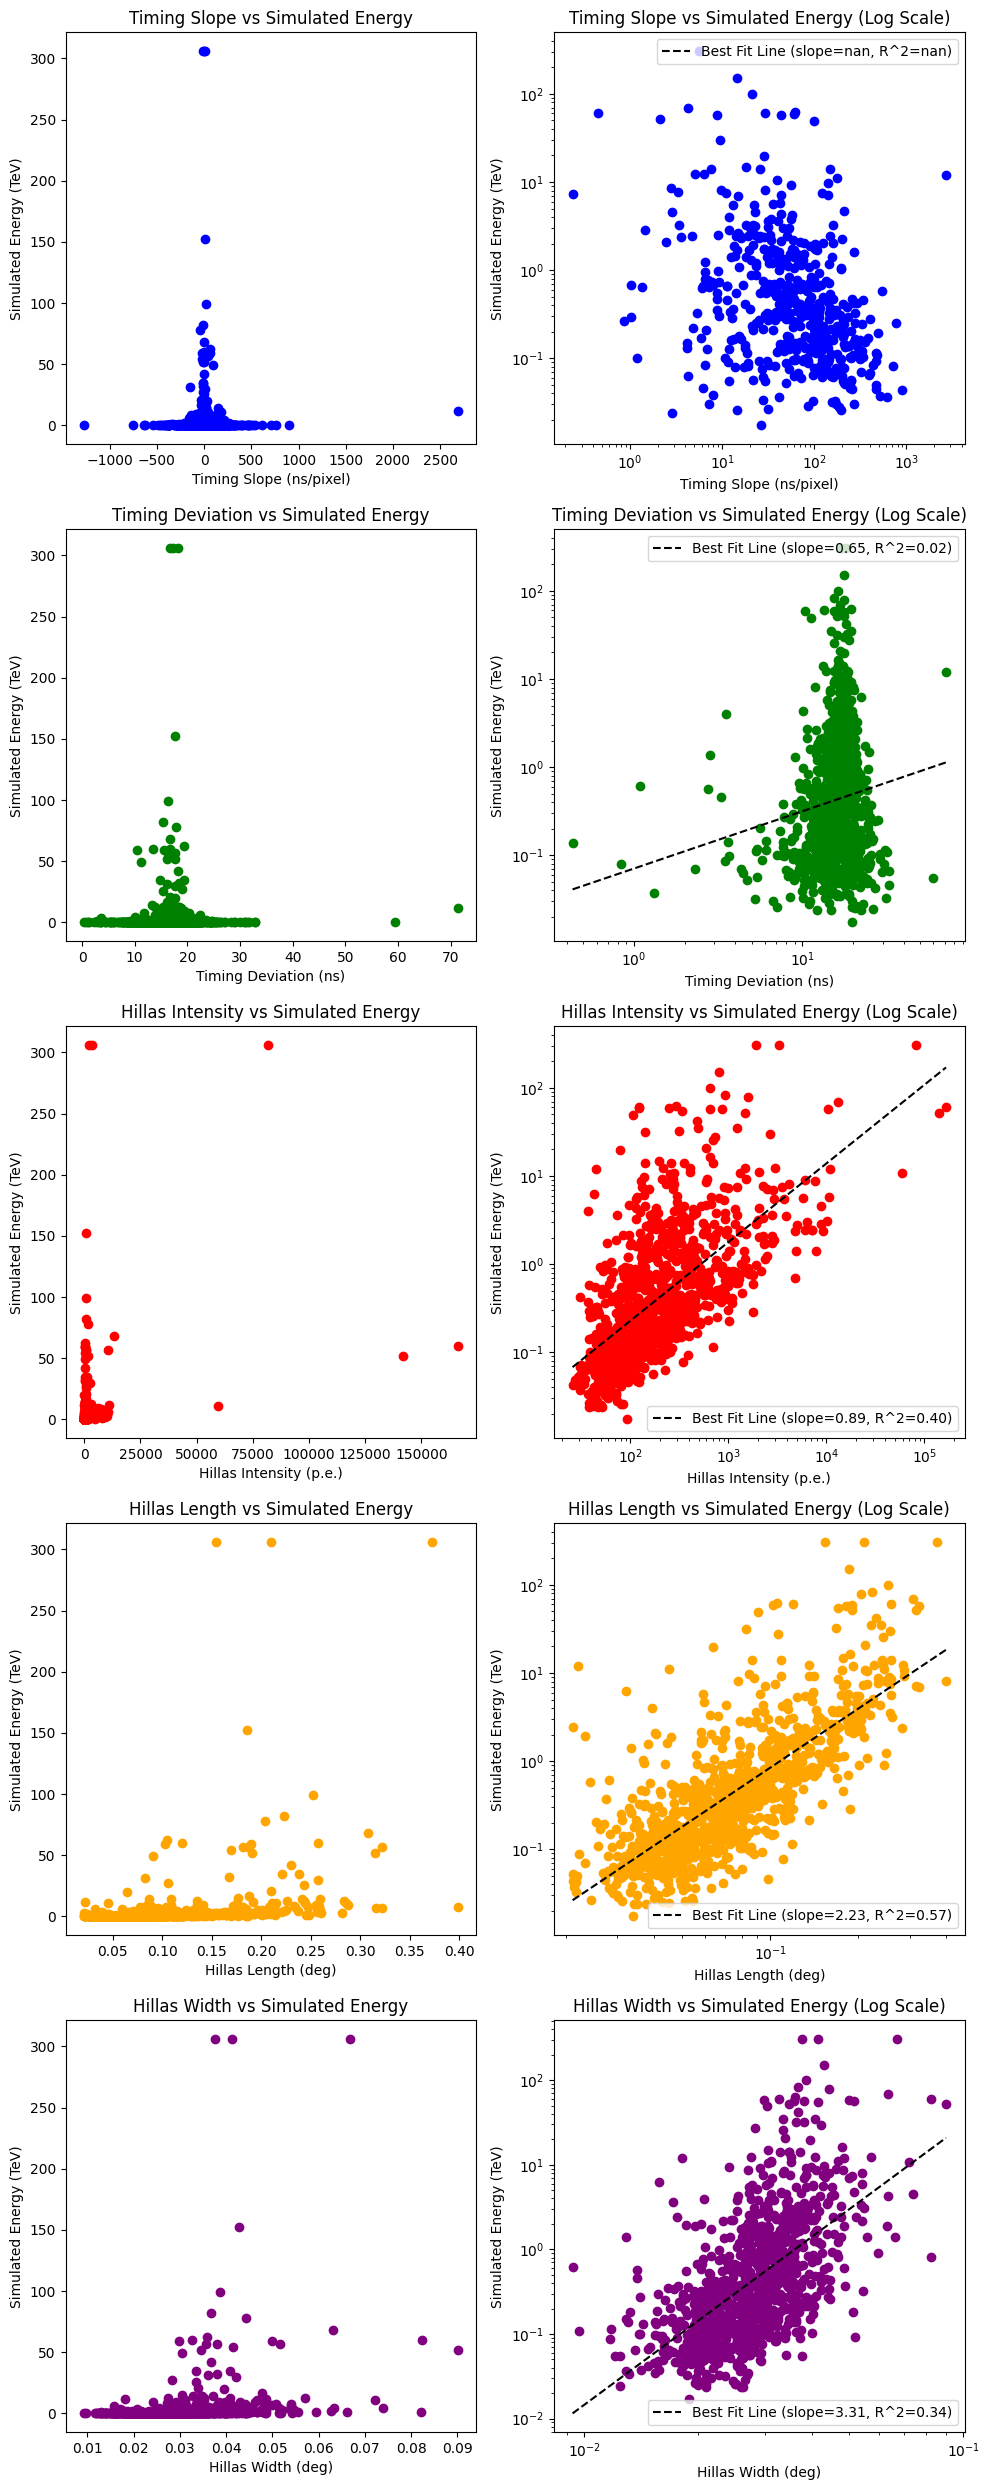

In [33]:
fig, ax = plt.subplots(5,2, figsize=(10, 25))
## time-slope and simulated energy
ax[0,0].plot(time_slope_array, sim_energy_array, 'o', color='blue')
ax[0,0].set_xlabel('Timing Slope (ns/pixel)')
ax[0,0].set_ylabel('Simulated Energy (TeV)')
ax[0,0].set_title('Timing Slope vs Simulated Energy')
## time-deviation and simulated energy
ax[1,0].plot(time_deviation_array, sim_energy_array, 'o', color='green')
ax[1,0].set_xlabel('Timing Deviation (ns)')
ax[1,0].set_ylabel('Simulated Energy (TeV)')
ax[1,0].set_title('Timing Deviation vs Simulated Energy')
## intensity and simulated energy
ax[2,0].plot(hillas_intensity_array, sim_energy_array, 'o', color='red')
ax[2,0].set_xlabel('Hillas Intensity (p.e.)')
ax[2,0].set_ylabel('Simulated Energy (TeV)')
ax[2,0].set_title('Hillas Intensity vs Simulated Energy')
## length and simulated energy
ax[3,0].plot(hillas_length_array, sim_energy_array, 'o', color='orange')
ax[3,0].set_xlabel('Hillas Length (deg)')
ax[3,0].set_ylabel('Simulated Energy (TeV)')
ax[3,0].set_title('Hillas Length vs Simulated Energy')
## width and simulated energy
ax[4,0].plot(hillas_width_array, sim_energy_array, 'o', color='purple')
ax[4,0].set_xlabel('Hillas Width (deg)')
ax[4,0].set_ylabel('Simulated Energy (TeV)')
ax[4,0].set_title('Hillas Width vs Simulated Energy')
## plotting correspponding logarithmic scatters on the right column
## time-slope and simulated energy
ax[0,1].plot(time_slope_array, sim_energy_array, 'o', color='blue')
ax[0,1].set_xlabel('Timing Slope (ns/pixel)')
ax[0,1].set_ylabel('Simulated Energy (TeV)')
ax[0,1].set_title('Timing Slope vs Simulated Energy (Log Scale)')
ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
## time-deviation and simulated energy
ax[1,1].plot(time_deviation_array, sim_energy_array, 'o', color='green')
ax[1,1].set_xlabel('Timing Deviation (ns)')
ax[1,1].set_ylabel('Simulated Energy (TeV)')
ax[1,1].set_title('Timing Deviation vs Simulated Energy (Log Scale)')
ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')
## intensity and simulated energy
ax[2,1].plot(hillas_intensity_array, sim_energy_array, 'o', color='red')
ax[2,1].set_xlabel('Hillas Intensity (p.e.)')
ax[2,1].set_ylabel('Simulated Energy (TeV)')
ax[2,1].set_title('Hillas Intensity vs Simulated Energy (Log Scale)')
ax[2,1].set_yscale('log')
ax[2,1].set_xscale('log')
## length and simulated energy
ax[3,1].plot(hillas_length_array, sim_energy_array, 'o', color='orange')
ax[3,1].set_xlabel('Hillas Length (deg)')
ax[3,1].set_ylabel('Simulated Energy (TeV)')
ax[3,1].set_title('Hillas Length vs Simulated Energy (Log Scale)')
ax[3,1].set_yscale('log')
ax[3,1].set_xscale('log')
## width and simulated energy
ax[4,1].plot(hillas_width_array, sim_energy_array, 'o', color='purple')
ax[4,1].set_xlabel('Hillas Width (deg)')
ax[4,1].set_ylabel('Simulated Energy (TeV)')
ax[4,1].set_title('Hillas Width vs Simulated Energy (Log Scale)')
ax[4,1].set_yscale('log')
ax[4,1].set_xscale('log')

## overlaying the lines of best fit on the log-log graphs, printing slope and R^2 values for each line of best fit
from scipy.stats import linregress
def plot_best_fit_line(x, y, ax):
    log_x = np.log10(x)
    log_y = np.log10(y)
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    x_fit = np.linspace(min(log_x), max(log_x), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(10**x_fit, 10**y_fit, color='black', linestyle='--', label=f'Best Fit Line (slope={slope:.2f}, R^2={r_value**2:.2f})')
    ax.legend()
plot_best_fit_line(time_slope_array, sim_energy_array, ax[0,1])
plot_best_fit_line(time_deviation_array, sim_energy_array, ax[1,1])
plot_best_fit_line(hillas_intensity_array, sim_energy_array, ax[2,1])
plot_best_fit_line(hillas_length_array, sim_energy_array, ax[3,1])
plot_best_fit_line(hillas_width_array, sim_energy_array, ax[4,1])

plt.tight_layout()
plt.show()

From the graphs above, it can be seen that:
- The slope of the time profile has the least correlation with the simulated energy.
- The spread of the timing profile has a very weak correlation with the simulated energy.
- Hillas intensity and the simulated energy have a postive correlation.
- Hillas length and width, also have a positive correlation with simulaed energy.
These are all sensible, because as the energy of the shower source increases, it is expected that the intensity of the Cherenkov light that the shower emits is more intense, and wide and penetrates a greater atmospheric depth, as it's maximum is more likely to occur at a greater depth.